In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
data = pd.read_csv(
    "C:/Users/Tiarn/Documents/Data Science/Project/PPR-ALL.csv",
    encoding="cp1252",
    encoding_errors="ignore"
)

C:\Users\Tiarn\AppData\Local\Temp\ipykernel_2188\648358817.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(


In [8]:
# --- Clean the Price column ---
# Remove €, commas, periods, convert to float
data['Price'] = data['Price (€)'].replace('[€,.]', '', regex=True).astype(float)


In [10]:
# --- Parse the date column ---
data['Date'] = pd.to_datetime(data['Date of Sale (dd/mm/yyyy)'],
                            dayfirst=True, errors='coerce')

In [11]:
# Drop rows with invalid or missing dates
data = data.dropna(subset=['Date'])

In [13]:
# --- Compute monthly average house price ---
monthly = data.set_index('Date').resample('ME')['Price'].mean()

In [14]:
# --- Compute a rolling average ---
# Change window size to 3, 6, or 12 months if you want
rolling = monthly.rolling(window=3).mean()

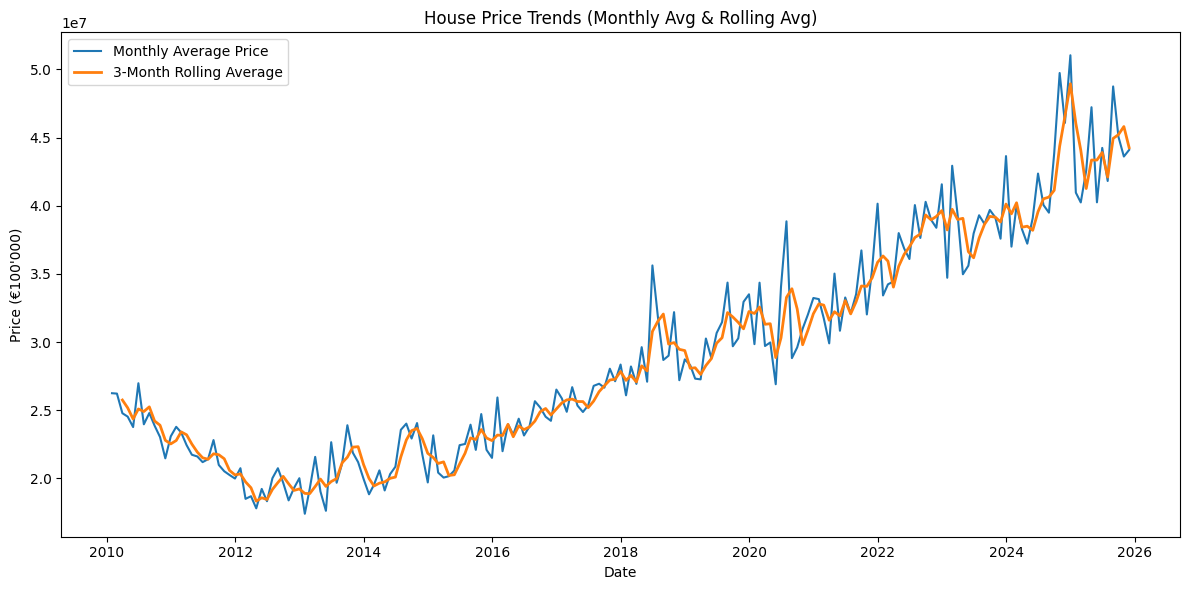

In [16]:
# --- Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(monthly, label='Monthly Average Price')
plt.plot(rolling, label='3-Month Rolling Average', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Price (€100\'000)')
plt.title('House Price Trends (Monthly Avg & Rolling Avg)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Tiarn\AppData\Local\Temp\ipykernel_2188\2881734652.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_dublin = df_dublin.set_index('Date').resample('M')['Price'].mean()


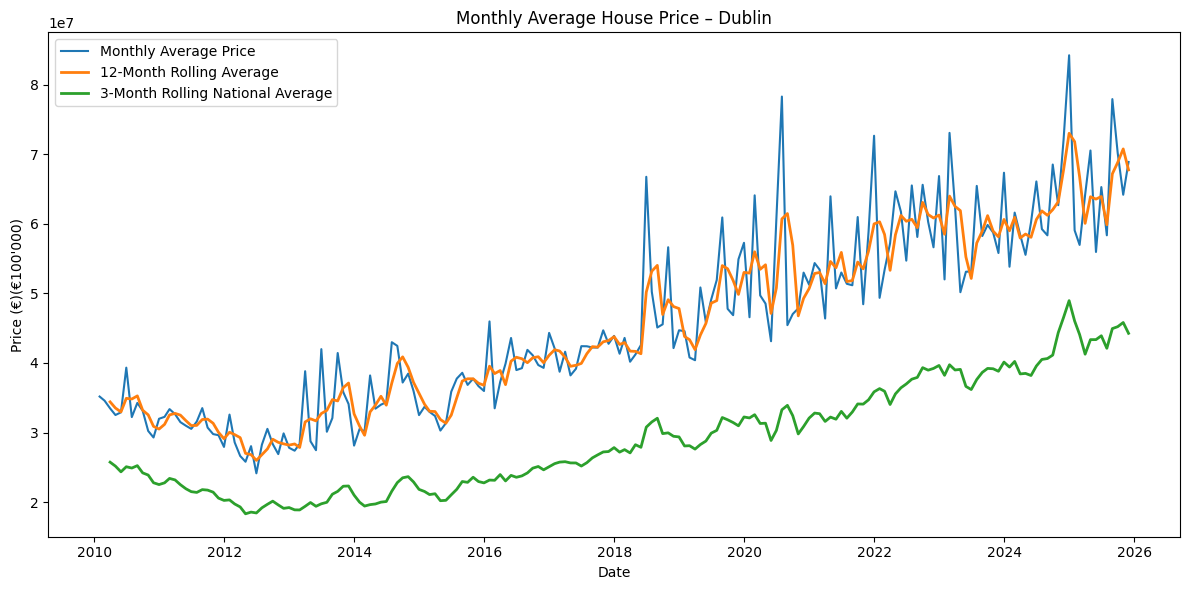

In [ ]:
# Filter for Dublin only
data_dublin = data[data['County'] == 'Dublin']

# Monthly average
monthly_dublin = data_dublin.set_index('Date').resample('M')['Price'].mean()

# Rolling average
rolling_dublin = monthly_dublin.rolling(window=3).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_dublin, label='Monthly Average Price')
plt.plot(rolling_dublin, label='12-Month Rolling Average', linewidth=2)
plt.plot(rolling, label='3-Month Rolling National Average', linewidth=2)
plt.title('Monthly Average House Price – Dublin')
plt.xlabel('Date')
plt.ylabel('Price (€)(€100\'000)')
plt.legend()
plt.tight_layout()
plt.show()


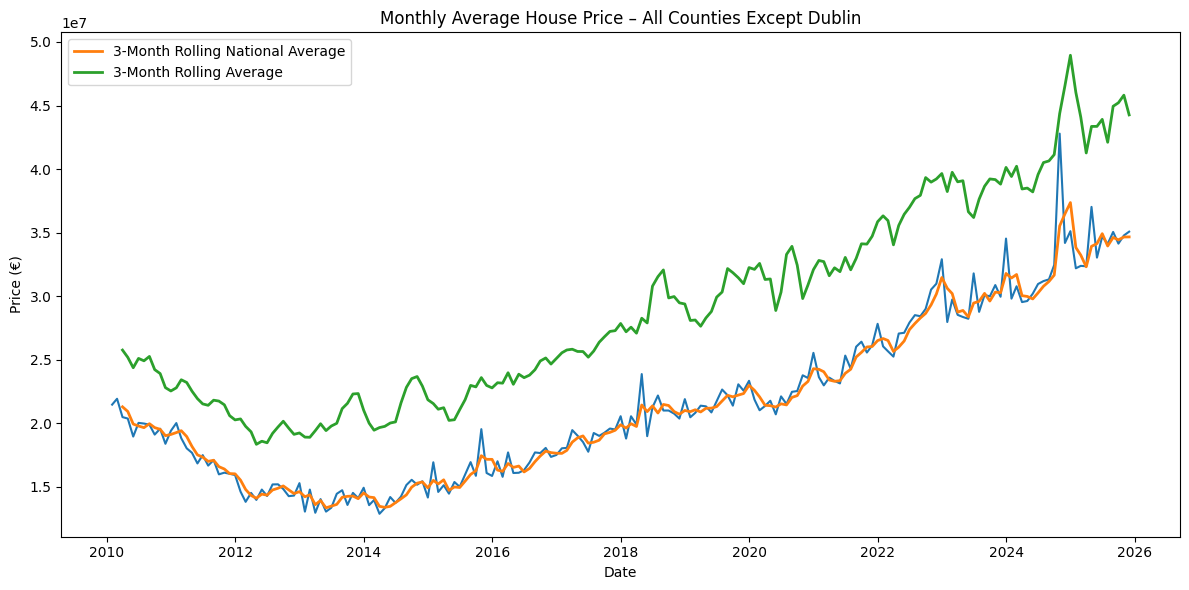

In [ ]:
# Filter for non-Dublin counties
data_rest = data[data['County'] != 'Dublin']

# Monthly average
monthly_rest = data_rest.set_index('Date').resample('ME')['Price'].mean()
rolling_rest = monthly_rest.rolling(window=3).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_rest)
#plt.plot(rolling_dublin, label='12-Month Rolling Average', linewidth=2)
plt.plot(rolling_rest, label='3-Month Rolling National Average', linewidth=2)
plt.plot(rolling, label='3-Month Rolling Average', linewidth=2)
plt.title('Monthly Average House Price – All Counties Except Dublin')
plt.xlabel('Date')
plt.ylabel('Price (€)')
plt.tight_layout()
plt.legend()
plt.show()


C:\Users\Tiarn\AppData\Local\Temp\ipykernel_2188\1956268129.py:10: MatplotlibDeprecationWarning: Passing label as a length 191 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(rolling_cities, label=rolling)


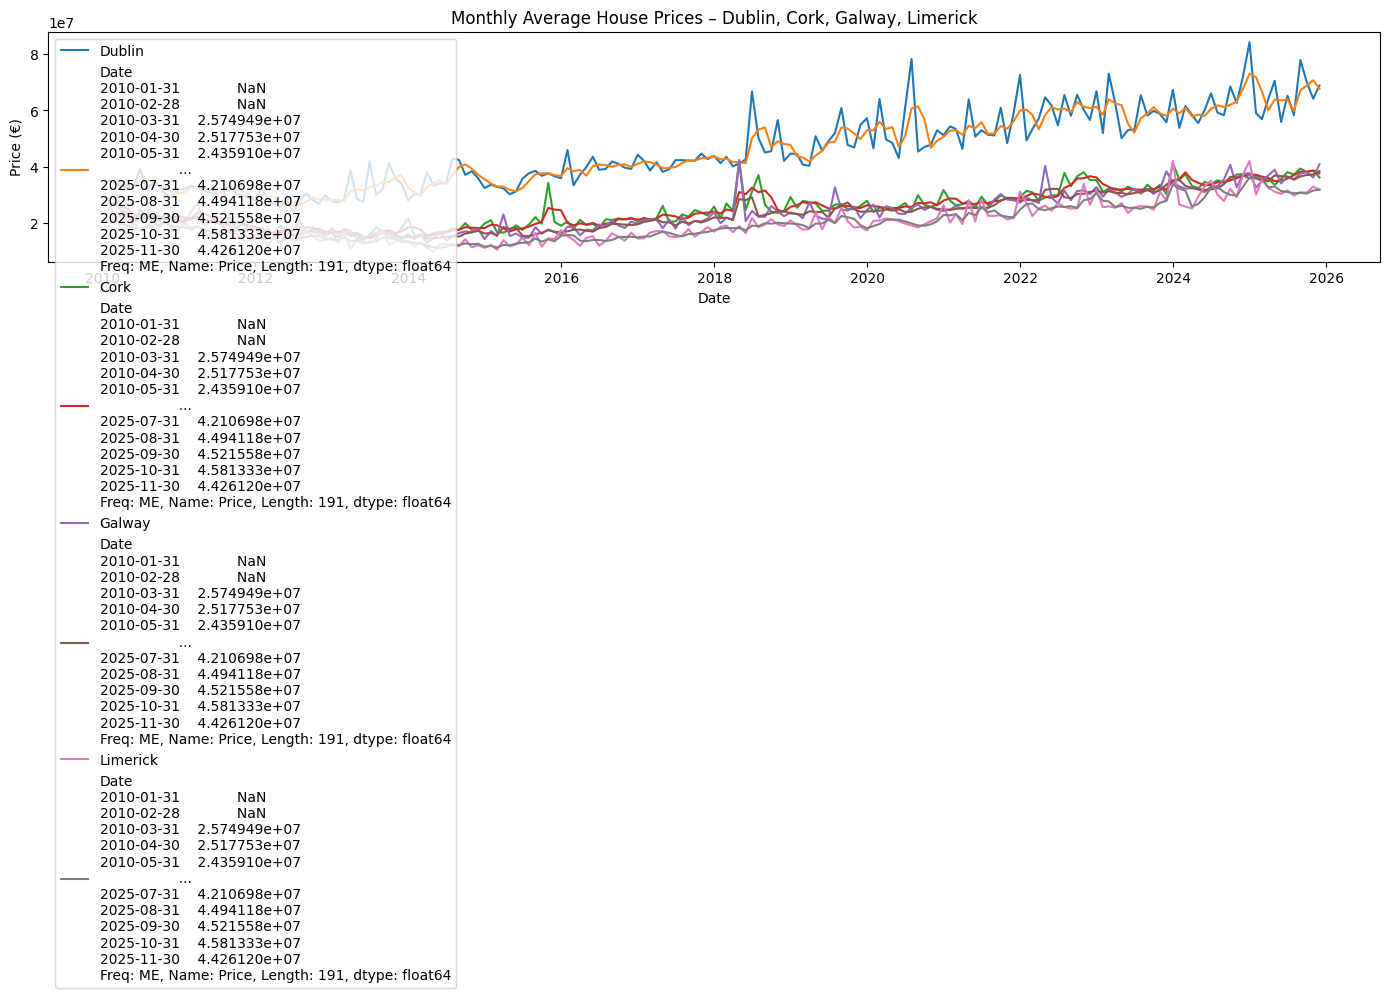

In [39]:
counties = ['Dublin', 'Cork', 'Galway', 'Limerick']

plt.figure(figsize=(14,7))

for county in counties:
    subset = data[data['County'] == county]
    monthly_cities = subset.set_index('Date').resample('ME')['Price'].mean()
    rolling_cities = monthly_cities.rolling(window=3).mean()
    plt.plot(monthly_cities, label=county)
    plt.plot(rolling_cities, label=rolling)

plt.title('Monthly Average House Prices – Dublin, Cork, Galway, Limerick')
plt.xlabel('Date')
plt.ylabel('Price (€)')
plt.legend()
plt.tight_layout()
plt.show()
